# Transformer on PLAsTiCC: using GP fits to lightcurves

This notebook uses the `dlip_plasticc` package on top of `avocado`.

### Notebook parameters

In [1]:
# Notebook parameters

CONFIG_DEFAULT_PATH = '/home6/s4339150/Courses/dlip_plasticc/configs/default.toml'
CONFIG_LOCAL_PATH = '/home6/s4339150/Courses/dlip_plasticc/configs/local.toml'

# Training
TRAIN_DATASET_NAME = 'plasticc_augment_gp'
CLASSIFIER_NAME = 'my_transformer_gp'
SEQ_LEN = 350
NUM_EPOCHS = 60
BATCH_SIZE = 64
LR = 1e-4
NUM_FOLDS = 5
RANDOM_STATE = 42
VAL_FOLD = 0
WEIGHT_DECAY = 5e-2
LR_SCHEDULER_FACTOR = 0.5
LR_SCHEDULER_PATIENCE = 2
MIN_LR = 1e-6
EARLY_STOPPING_PATIENCE = 8

# Transformer architecture
D_MODEL = 128
NHEAD = 4
NUM_LAYERS = 4
DIM_FEEDFORWARD = 512
DROPOUT = 0.3

# Prediction
TEST_DATASET_NAME = 'plasticc_test_gp'
TOTAL_CHUNKS = 500

# Change this list to the chunks you actually want to run.
# For a quick smoke test, use something like [0, 1, 2].
CHUNKS = range(21)

# Output location for per-chunk and combined predictions.
OUT_DIR = 'notebook_outputs/transformer_GP_predictions'

# Confusion matrix display options
CONFUSION_NORMALIZE = 'true'  # one of: None, 'true', 'pred', 'all'
FIGSIZE_HISTORY = (8, 5)
FIGSIZE_CONFUSION = (10, 8)


### Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
import gc
import torch
import torch.nn.functional as F

from pathlib import Path

import avocado

from dlip_plasticc.config import load_config, apply_avocado_settings
from dlip_plasticc.features import PlasticcSequenceFeaturizer
from dlip_plasticc.models import TransformerClassifier
from dlip_plasticc.pipelines.predict import predict_partial_from_dataset
from dlip_plasticc.pipelines.score import score_flat, align_truth_and_predictions

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


### Paths

These are set by the `avocado_settings.json` file.

In [3]:
cfg = load_config(CONFIG_DEFAULT_PATH, CONFIG_LOCAL_PATH)
apply_avocado_settings(cfg)

print('Using avocado paths:')
print('  data_directory       =', avocado.settings['data_directory'])
print('  features_directory   =', avocado.settings['features_directory'])
print('  predictions_directory=', avocado.settings['predictions_directory'])
print('  classifier_directory =', avocado.settings['classifier_directory'])


Using avocado paths:
  data_directory       = /scratch/s4339150/plasticc/data
  features_directory   = /scratch/s4339150/plasticc/features
  predictions_directory= /scratch/s4339150/plasticc/predictions
  classifier_directory = /scratch/s4339150/plasticc/classifiers


## 1. Preprocess the data

We use gaussian-process fitted lightcurves, but since they are different from the default datasets avocado expects (e.g. features, or raw data), we need some preprocessing.

In [4]:
with h5py.File('/scratch/s4339150/plasticc/data/plasticc_augment_gp.h5', 'r') as f:
    object_id     = f['object_id'][:].astype(str)
    cont_features = f['cont_features'][:]
    band_ids      = f['band_ids'][:]
    mask          = f['mask'][:]

print('object_id:',     object_id.shape)
print('cont_features:', cont_features.shape)
print('band_ids:',      band_ids.shape)
print('mask:',          mask.shape)

object_id: (66532,)
cont_features: (66532, 200, 13)
band_ids: (66532, 200)
mask: (66532, 200)


In [5]:
class H5TrainDataset:
    def __init__(self, h5_path, avocado_dataset):
        with h5py.File(h5_path, 'r') as f:
            object_ids         = f['object_id'][:].astype(str)
            self.cont_features = f['cont_features'][:]
            self.band_ids      = f['band_ids'][:]
            self.mask          = f['mask'][:]

        self._object_ids      = object_ids
        self._avocado_dataset = avocado_dataset
        self.metadata         = avocado_dataset.metadata.loc[object_ids]

    def select_features(self, featurizer):
        return (self.cont_features, self.band_ids, self.mask)

    def label_folds(self, num_folds, random_state):
        folds = self._avocado_dataset.label_folds(num_folds, random_state)
        # re-index to match h5 row order exactly
        return folds.loc[self._object_ids].reset_index(drop=True)
    
print(f"Loading training dataset '{TRAIN_DATASET_NAME}'...")
avocado_dataset = avocado.load('plasticc_augment', metadata_only=True)  # no .metadata
train_dataset   = H5TrainDataset(
    '/scratch/s4339150/plasticc/data/plasticc_augment_gp.h5',
    avocado_dataset,
)

Loading training dataset 'plasticc_augment_gp'...


### Determine class weights

In [6]:
# get class counts from training metadata
metadata = avocado.load('plasticc_augment', metadata_only=True).metadata
class_counts = metadata['class'].value_counts()

# dampened inverse frequency 
DAMPING = 0.5 # raise to power < 1 to soften the effect
inv_freq = 1.0 / class_counts
inv_freq = inv_freq ** DAMPING
inv_freq = inv_freq / inv_freq.mean()  # normalize so mean = 1

class_weights = inv_freq.to_dict()
print(class_weights)

{90: 0.34116945356222383, 16: 0.46866690606518574, 42: 0.47171363514681625, 65: 0.49707336968789073, 15: 0.653113240214203, 88: 0.7676151713723466, 62: 0.7813406086647082, 92: 0.8897307573446831, 95: 1.0895895743533481, 6: 1.1697398625334794, 67: 1.2021887265368671, 52: 1.2476368499082122, 64: 1.909131498227198, 53: 2.5112903463828395}


## 2. Train the transformer


In [7]:
gc.collect()
torch.cuda.empty_cache()

classifier = TransformerClassifier(
    name=CLASSIFIER_NAME,
    featurizer=None,       
    num_epochs=NUM_EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LR,
    d_model=D_MODEL,
    nhead=NHEAD,
    num_layers=NUM_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD,
    dropout=DROPOUT,
    auto_class_weights=False,  
    class_weights=class_weights, 
)

print(f"Training classifier '{CLASSIFIER_NAME}'...")
classifier.train(
    train_dataset,
    num_folds=NUM_FOLDS,
    random_state=RANDOM_STATE,
    val_fold=VAL_FOLD,
    weight_decay=WEIGHT_DECAY,
    lr_scheduler_factor=LR_SCHEDULER_FACTOR,
    lr_scheduler_patience=LR_SCHEDULER_PATIENCE,
    min_lr=MIN_LR,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    show_progress=True,
)

print(f"Best validation loss: {classifier.best_val_loss:.5f}")

Training classifier 'my_transformer_gp'...


Epochs:   0%|          | 0/60 [00:00<?, ?it/s]/home6/s4339150/miniconda/envs/project/lib/python3.10/site-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(
Epochs:   2%|▏         | 1/60 [00:12<11:58, 12.17s/it]

Epoch 1 train_loss: 1.59521 val_loss: 1.27588 val_acc: 0.60999 lr: 1.000000e-04


Epochs:   3%|▎         | 2/60 [00:23<11:27, 11.85s/it]

Epoch 2 train_loss: 1.26019 val_loss: 1.16855 val_acc: 0.63550 lr: 1.000000e-04


...

Epoch 38 train_loss: 0.84181 val_loss: 0.93186 val_acc: 0.69923 lr: 1.562500e-06


Epochs:  65%|██████▌   | 39/60 [11:59<07:58, 22.78s/it]

Epoch 39 train_loss: 0.84290 val_loss: 0.93475 val_acc: 0.69930 lr: 1.562500e-06


Epochs:  65%|██████▌   | 39/60 [12:22<06:39, 19.04s/it]

Epoch 40 train_loss: 0.84217 val_loss: 0.93582 val_acc: 0.69818 lr: 1.562500e-06
Early stopping at epoch 40. Best val_loss: 0.93020
Best validation loss: 0.93020
Best validation loss: 0.93020


In [8]:
# Save the trained classifier
classifier.write(overwrite=True)
print('Classifier written to:', classifier.path)


Classifier written to: /scratch/s4339150/plasticc/classifiers/classifier_my_transformer_gp.pkl


## 2. Plot training history

In [9]:
history = classifier.history.copy()
history.tail()

,epoch,train_loss,val_loss,val_acc,lr
35,36,0.844593,0.937109,0.699454,0.000003
36,37,0.844742,0.933609,0.699155,0.000003
37,38,0.841814,0.931863,0.699230,0.000002
38,39,0.842902,0.934752,0.699304,0.000002
39,40,0.842172,0.935815,0.698182,0.000002


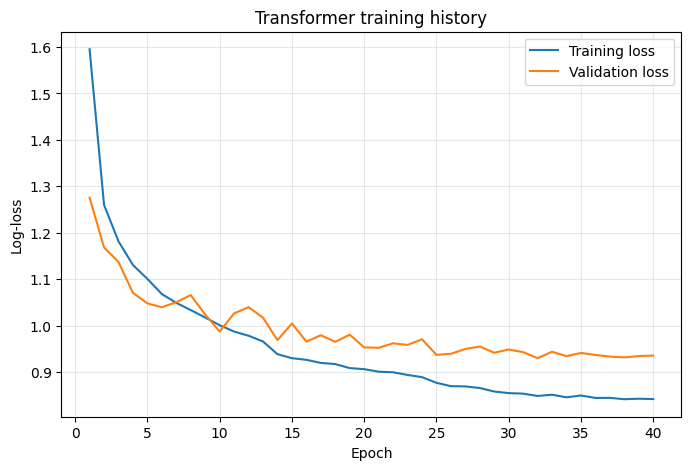

In [ ]:
fig, ax = plt.subplots(figsize=FIGSIZE_HISTORY)
ax.plot(history['epoch'], history['train_loss'], label='Training loss')
ax.plot(history['epoch'], history['val_loss'], label='Validation loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Log-loss')
ax.set_title('Transformer training history: GP fits')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


## 3. Predict on test set

In [13]:
# Load the trained classifier for prediction and scoring if needed 
classifier = avocado.load_classifier(CLASSIFIER_NAME)

### Prepare test set

In [14]:
class H5TestDataset:
    def __init__(self, h5_path, avocado_dataset):
        with h5py.File(h5_path, 'r') as f:
            object_ids         = f['object_id'][:].astype(str)
            self.cont_features = f['cont_features'][:]
            self.band_ids      = f['band_ids'][:]
            self.mask          = f['mask'][:]

        self._object_ids      = object_ids
        self._avocado_dataset = avocado_dataset
        # use reindex instead of loc — fills missing ids with NaN instead of KeyError
        self.metadata         = avocado_dataset.metadata.reindex(object_ids)

    def select_features(self, featurizer):
        return (self.cont_features, self.band_ids, self.mask)

    def label_folds(self, num_folds, random_state):
        folds = self._avocado_dataset.label_folds(num_folds, random_state)
        return folds.loc[self._object_ids].reset_index(drop=True)


avocado_test = avocado.load('plasticc_test', metadata_only=True)
test_dataset = H5TestDataset('/scratch/s4339150/plasticc/data/plasticc_test_gp.h5', avocado_test)


### Predict

In [16]:

def predict_batched(classifier, dataset, batch_size=512):
    """Predict in batches to avoid OOM."""
    cont_features, band_ids, mask = dataset.select_features(None)
    global_feats = classifier._derive_global_features(cont_features, mask)

    n = cont_features.shape[0]
    all_probs = []

    classifier.model.eval()
    with torch.no_grad():
        for start in range(0, n, batch_size):
            end = min(start + batch_size, n)

            xc = torch.tensor(cont_features[start:end], dtype=torch.float32).to(classifier.device)
            xb = torch.tensor(band_ids[start:end],      dtype=torch.long).to(classifier.device)
            m  = torch.tensor(mask[start:end],           dtype=torch.float32).to(classifier.device)
            g  = torch.tensor(global_feats[start:end],  dtype=torch.float32).to(classifier.device)

            logits = classifier.model(xc, xb, m, g)
            probs  = F.softmax(logits, dim=1).cpu().numpy()
            all_probs.append(probs)

    all_probs = np.concatenate(all_probs, axis=0)

    return pd.DataFrame(
        all_probs,
        index=dataset.metadata.index,
        columns=classifier.class_names,
    )

# usage
preds = predict_batched(classifier, test_dataset, batch_size=512)
print(preds.shape)
preds.head()

(146701, 14)


,6,15,16,42,52,53,62,64,65,67,88,90,92,95
object_id,,,,,,,,,,,,,,
plasticc_000000013,0.000394,0.000132,0.000011,0.634252,0.042324,1.312641e-05,0.094372,0.000021,0.000161,0.001395,0.000537,0.012776,9.448844e-06,0.213602
plasticc_000000014,0.000025,0.000510,0.000002,0.920771,0.024740,8.193584e-08,0.030361,0.000019,0.003628,0.000216,0.000272,0.018211,1.807651e-06,0.001243
plasticc_000000017,0.000056,0.000802,0.000054,0.754289,0.121479,7.244614e-06,0.060600,0.000356,0.011439,0.002448,0.003485,0.037876,1.375399e-04,0.006971
plasticc_000000023,0.011418,0.000191,0.000004,0.162124,0.038530,7.182497e-07,0.417434,0.000885,0.001140,0.076254,0.000052,0.220893,2.081862e-07,0.071075
plasticc_000000034,0.000036,0.000180,0.000002,0.034161,0.132951,6.555569e-08,0.014669,0.000005,0.000026,0.002350,0.000089,0.813588,1.268277e-06,0.001943


## 4. Score predictions with avocado flat-weighted logloss

In [17]:
flat_score, n_scored = score_flat(
    avocado_test.metadata,   # pass metadata directly 
    preds,
)
print(f'Flat-weighted logloss: {flat_score:.5f}')
print(f'Objects scored:        {n_scored:,}')

Flat-weighted logloss: 0.95573
Objects scored:        146,085


## 5. Confusion matrix and classification report

In [ ]:
# Labels for plots

plot_labels = {
    6: 'Single micro-lens - 6',
    15: 'TDE - 15',
    16: 'Eclipsing Binary - 16',
    42: 'SNII - 42',
    52: 'SNIax - 52',
    53: 'Mira - 53',
    62: 'SNIbc - 62',
    64: 'Kilonova - 64',
    65: 'M-dwarf - 65',
    67: 'SNIa-91bg - 67',
    88: 'AGN - 88',
    90: 'SNIa - 90',
    92: 'RR lyrae - 92',
    95: 'SLSN-I - 95',
    99: 'Unknown - 99',
}

plot_labels_short = {
    6: 'Single $\mu$-lens - 6',
    15: 'TDE - 15',
    16: 'Eclip. Binary - 16',
    42: 'SNII - 42',
    52: 'SNIax - 52',
    53: 'Mira - 53',
    62: 'SNIbc - 62',
    64: 'Kilonova - 64',
    65: 'M-dwarf - 65',
    67: 'SNIa-91bg - 67',
    88: 'AGN - 88',
    90: 'SNIa - 90',
    92: 'RR lyrae - 92',
    95: 'SLSN-I - 95',
    99: 'Unknown - 99',
}

plot_labels_extra_short = {
    6: 'Single $\mu$-lens',
    15: 'TDE',
    16: 'Eclip. Binary',
    42: 'SNII',
    52: 'SNIax',
    53: 'Mira',
    62: 'SNIbc',
    64: 'Kilonova',
    65: 'M-dwarf',
    67: 'SNIa-91bg',
    88: 'AGN',
    90: 'SNIa',
    92: 'RR lyrae',
    95: 'SLSN-I',
    99: 'Unknown',
}

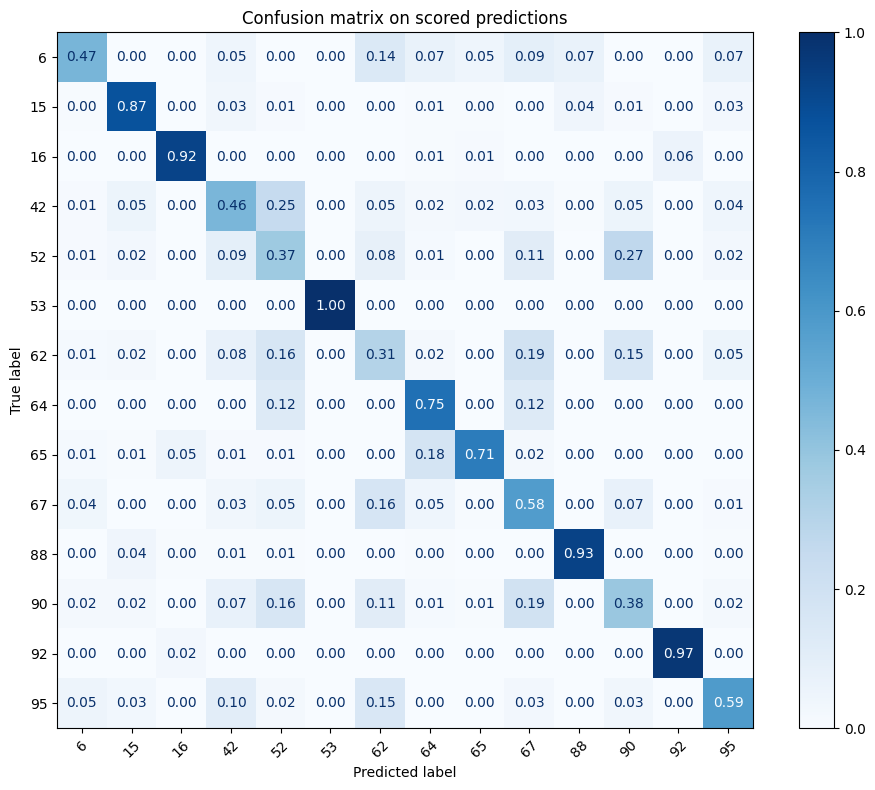

In [51]:
y_true, pred_aligned = align_truth_and_predictions(
    avocado_test.metadata,
    preds,
    known_classes_only=True,
    normalize=True,
)

y_pred = pred_aligned.idxmax(axis=1)
labels = sorted(np.unique(np.concatenate([y_true.values, y_pred.values])))

# map numeric class ids to readable labels
display_labels = [plot_labels_short.get(l, str(l)) for l in labels]

cm = confusion_matrix(y_true, y_pred, labels=labels, normalize=CONFUSION_NORMALIZE)

fig, ax = plt.subplots(figsize=FIGSIZE_CONFUSION)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=display_labels,  # readable labels
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    colorbar=True,
    cmap=plt.cm.Blues,
    values_format=".2f",
)

ax.set_title("Confusion matrix on scored predictions")
plt.tight_layout()
plt.show()

In [27]:
print(classification_report(y_true, y_pred, digits=4))

              precision    recall  f1-score   support

           6     0.0108    0.4651    0.0211        43
          15     0.0853    0.8685    0.1553       479
          16     0.8872    0.9242    0.9053      3233
          42     0.7912    0.4619    0.5833     48142
          52     0.0422    0.3733    0.0758      2864
          53     0.7541    1.0000    0.8598        46
          62     0.1860    0.3067    0.2316      7859
          64     0.0020    0.7500    0.0040         8
          65     0.5823    0.7050    0.6378      3095
          67     0.0569    0.5780    0.1037      1673
          88     0.9019    0.9287    0.9151      3743
          90     0.8438    0.3834    0.5273     66848
          92     0.9724    0.9724    0.9724      6781
          95     0.1550    0.5854    0.2451      1271

    accuracy                         0.4709    146085
   macro avg     0.4479    0.6645    0.4455    146085
weighted avg     0.7604    0.4709    0.5537    146085

